# 07 · Explorador de microdatos APRENDER 2024 (Primaria 3° y Secundaria 5°/6°)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/santiagoriverti/analisis_pruebas_aprender/blob/main/07_explorador_microdatos.ipynb)

Herramienta para **cruzar dos variables** de los microdatos 2024 y ver el resultado **ponderado** al instante, con menús:

| Elegís | Opciones |
|---|---|
| **Base** | Secundaria 5°/6° (censal) · Primaria 3° (lectura, muestral) |
| **Medida** | % en niveles altos · % en niveles bajos · puntaje medio · distribución de niveles · % de estudiantes |
| **Área** | Lengua o Matemática (Secundaria) · Lectura (Primaria) |
| **Filas** y **abrir por** | cualquier variable de contexto, provincia, sector, ámbito, NSE de la escuela, niveles de desempeño… |
| **Filtros** | provincia, sector, ámbito (Secundaria), NSE de la escuela (Primaria) |

- **Niveles altos:** Satisfactorio + Avanzado (Secundaria) · Niveles IV y V (Primaria). **Niveles bajos:** Por debajo del
  básico (Secundaria) · Lector incipiente a Nivel II (Primaria).
- **% de estudiantes:** distribución de la variable de *abrir por* dentro de cada fila (suma 100 % por fila). Sirve para ver
  cómo se relacionan dos variables de contexto (p. ej. libros × educación de la madre).
- **Ponderadores:** `ponderL` / `ponderM` para desempeño en Lengua (o Lectura) / Matemática; `ponder` para % de estudiantes.
- **†** = celda con menos de 50 estudiantes (estimación inestable, sobre todo en Primaria, que es muestral).
- Datos **anonimizados**: no se muestran escuelas individuales. **Asociación, no causa.**

**Cómo usarlo:** *Entorno de ejecución → Ejecutar todo*, autorizar Drive y usar los menús de la sección 3. Si preferís
escribir, la función `explorar(...)` hace lo mismo (sección 4 tiene ejemplos listos).

**Requisito:** en *Mi unidad/`pruebas_aprender`* los zip `2024 Base de microdatos Aprender primaria.zip` y
`2024 Base de microdatos Aprender secundaria.zip` (los mismos que usa el 06).

---
## 0 · Setup y carga de los microdatos

In [1]:
import os, re, sys, glob, subprocess, textwrap, unicodedata, zipfile
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display, HTML

def in_colab():
    try:
        import google.colab  # noqa
        return True
    except ImportError:
        return False

try:
    import pyreadstat
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pyreadstat'], check=True)
    import pyreadstat
import ipywidgets as W

def _n(s):
    s = unicodedata.normalize('NFKD', str(s)).encode('ascii', 'ignore').decode().lower()
    return re.sub(r'[^a-z0-9]+', ' ', s).strip()

if in_colab():
    from google.colab import drive
    drive.mount('/content/drive')
    CARPETA, EXTRAER = '/content/drive/MyDrive/pruebas_aprender', '/content/microdatos_2024'
else:
    CARPETA, EXTRAER = os.path.join(os.getcwd(), 'resultados_aprender'), os.path.join(os.getcwd(), 'microdatos_2024_tmp')

def ubicar_sav(nivel):
    """Extrae el .sav del zip de `nivel` ('primaria' | 'secundaria') o, si no hay zip, usa el .sav local."""
    zips = [f for f in glob.glob(os.path.join(CARPETA, '*.zip')) if 'microdato' in _n(os.path.basename(f)) and nivel in _n(os.path.basename(f))]
    if zips:
        with zipfile.ZipFile(zips[0]) as zf:
            savs = [m for m in zf.namelist() if m.lower().endswith('.sav')]
            assert savs, f'El zip {os.path.basename(zips[0])} no tiene archivos .sav. Contenido: {zf.namelist()}'
            nombre = max(savs, key=lambda m: zf.getinfo(m).file_size)
            destino = os.path.join(EXTRAER, nivel)
            if not os.path.exists(os.path.join(destino, nombre)):
                zf.extract(nombre, destino)
            return os.path.join(destino, nombre)
    ruta = os.path.join(CARPETA, 'Base_publica_prim_Ap2024.sav' if nivel == 'primaria' else 'Base_publica_Ap2024.sav')
    assert os.path.exists(ruta), (f'No encuentro el zip de microdatos de {nivel} en {CARPETA}. Subí '
                                  f'"2024 Base de microdatos Aprender {nivel}.zip" a Mi unidad/pruebas_aprender.')
    return ruta

def leer(nivel):
    df, meta = pyreadstat.read_sav(ubicar_sav(nivel), apply_value_formats=True)
    for c in df.columns:
        if df[c].dtype == object or str(df[c].dtype) == 'category':
            df[c] = df[c].astype('string').str.strip().replace({'': pd.NA})
    df['provincia'] = df.jurisdiccion.replace({'Ciudad Autónoma de Buenos Aires': 'CABA',
                                               'Tierra del Fuego, Antártida e Islas del Atlántico Sur': 'Tierra del Fuego'})
    return df, meta

SEC, META_S = leer('secundaria')
PRI, META_P = leer('primaria')

# Recursos del hogar (0–5), igual que el 06: madre con terciario completo, >50 libros, computadora, espacio, 2+ baños
comp = pd.concat([SEC.Nivel_Ed_MadreX.eq('Universitario - Terciario - Posgrado completo'), SEC.ap19X.eq('Mas de 50 libros'),
                  SEC.ap16g.eq('Sí'), SEC.ap15.eq('Sí'), SEC.ap17.isin(['2', '3 o más'])], axis=1)
completo = SEC[['Nivel_Ed_MadreX', 'ap19X', 'ap16g', 'ap15', 'ap17']].notna().all(axis=1)
SEC['recursos_hogar'] = comp.sum(axis=1).where(completo).astype('Int64').astype('string')

print(f'Secundaria: {len(SEC):,} estudiantes · Primaria: {len(PRI):,} estudiantes')

Secundaria: 386,882 estudiantes · Primaria: 91,264 estudiantes


---
## 1 · Variables disponibles
Etiqueta, categorías (en orden) y % ponderado de cada una. `vacío` = sin respuesta (se excluye de los cálculos).

In [2]:
PROVINCIAS = sorted(SEC.provincia.dropna().unique(), key=_n)
NIV4 = ['Por debajo del nivel básico', 'Básico', 'Satisfactorio', 'Avanzado']
NIV6 = ['Lector incipiente', 'Nivel I', 'Nivel II', 'Nivel III', 'Nivel IV', 'Nivel V']
NSE = ['Bajo', 'Medio Bajo', 'Medio', 'Medio Alto', 'Alto']

# nombre visible → (columna, orden de categorías, etiquetas legibles)
VARIABLES = {
 'Secundaria': {
  'Provincia': ('provincia', PROVINCIAS, {}),
  'Sector de gestión': ('sector', ['Estatal', 'Privado'], {}),
  'Ámbito': ('ambito', ['Urbano', 'Rural'], {}),
  'Sexo': ('Sexo', ['Femenino', 'Masculino'], {}),
  'Edad': ('Edad', ['17 años o menos', '18 años', '19 años o más'], {}),
  'Nivel educativo de la madre': ('Nivel_Ed_MadreX', ['Hasta secundaria incompleta', 'Hasta terciario  / universitario incompleto', 'Universitario - Terciario - Posgrado completo'],
                                  {'Hasta terciario  / universitario incompleto': 'Secundaria completa a terciario incompleto',
                                   'Universitario - Terciario - Posgrado completo': 'Terciario / universitario completo'}),
  'Libros en el hogar': ('ap19X', ['Menos de 6 libros', 'De 6 a 50 libros', 'Mas de 50 libros'], {'Mas de 50 libros': 'Más de 50 libros'}),
  'Computadora en el hogar': ('ap16g', ['Sí', 'No'], {}),
  'Espacio tranquilo para estudiar': ('ap15', ['Sí', 'No'], {}),
  'Baños en el hogar': ('ap17', ['1', '2', '3 o más'], {'1': '1 baño', '2': '2 baños', '3 o más': '3 o más baños'}),
  'Recursos del hogar (0–5)': ('recursos_hogar', ['0', '1', '2', '3', '4', '5'], {}),
  'Repitencia en primaria': ('ap25aX', ['No repeti en primaria', 'Repeti en primaria'], {'No repeti en primaria': 'No repitió', 'Repeti en primaria': 'Repitió'}),
  'Horas semanales de estudio': ('ap31X', ['Menos de 2 horas', 'Entre 2 y 4 horas', 'Mas de 4 horas'], {'Mas de 4 horas': 'Más de 4 horas'}),
  'Nivel en Lengua': ('ldesemp', NIV4, {}),
  'Nivel en Matemática': ('mdesemp', NIV4, {}),
 },
 'Primaria': {
  'Provincia': ('provincia', PROVINCIAS, {}),
  'Sector de gestión': ('sector', ['Estatal', 'Privado'], {}),
  'NSE de la escuela': ('NSE_escuela', NSE, {}),
  'Sexo': ('Sexo', ['Nena', 'Nene'], {}),
  'Edad': ('Edad', ['8 años o menos', '9 años o más'], {}),
  'Asistencia al jardín': ('Jardin', ['Sala de tres', 'Sala de cuatro', 'Sala de cinco / no asistió'],
                           {'Sala de tres': 'Sala de 3', 'Sala de cuatro': 'Sala de 4', 'Sala de cinco / no asistió': 'Sala de 5 o no asistió'}),
  'Repitió algún grado': ('Repitencia', ['No', 'Si'], {'Si': 'Sí'}),
  'Libros en el hogar': ('Libros', ['Veinte libros o menos', 'Más de veinte libros'], {'Veinte libros o menos': '20 o menos', 'Más de veinte libros': 'Más de 20'}),
  'Celular propio': ('ap08', ['Sí', 'No, pero uso el de mi mamá, papá o familiar', 'No'], {'No, pero uso el de mi mamá, papá o familiar': 'No, usa el de un familiar'}),
  'La familia pregunta qué hizo en la escuela': ('ap11', ['Sí', 'No'], {}),
  'La familia ayuda con la tarea': ('ap12', ['Sí', 'No'], {}),
  'Le gusta ir a la escuela': ('ap13', ['Sí, me gusta', 'No, no me gusta'], {'Sí, me gusta': 'Sí', 'No, no me gusta': 'No'}),
  'Maestra: explica hasta que entiende': ('ap15a', ['Sí', 'No'], {}),
  'Maestra: hace actividades que le gustan': ('ap15b', ['Sí', 'No'], {}),
  'Maestra: felicita cuando le sale bien': ('ap15c', ['Sí', 'No'], {}),
  'Maestra: ayuda cuando algo sale mal': ('ap15d', ['Sí', 'No'], {}),
  'Alguien de la familia le lee': ('ap17', ['Sí', 'No'], {}),
  'Nivel en Lectura': ('ldesemp', NIV6, {}),
 }}
BASES = {'Secundaria': SEC, 'Primaria': PRI}
AREAS = {'Secundaria': {'Lengua': ('ldesemp', 'lpuntaje', 'ponderL', NIV4, ['Satisfactorio', 'Avanzado'], ['Por debajo del nivel básico']),
                        'Matemática': ('mdesemp', 'mpuntaje', 'ponderM', NIV4, ['Satisfactorio', 'Avanzado'], ['Por debajo del nivel básico'])},
         'Primaria': {'Lectura': ('ldesemp', 'lpuntaje', 'ponderL', NIV6, ['Nivel IV', 'Nivel V'], ['Lector incipiente', 'Nivel I', 'Nivel II'])}}
MEDIDAS = ['% en niveles altos', '% en niveles bajos', 'Puntaje medio', 'Distribución de niveles', '% de estudiantes']
N_MIN = 50

for base, vs in VARIABLES.items():            # control: las categorías declaradas existen en los datos
    for nombre, (col, orden, _) in vs.items():
        faltan = set(orden) - set(BASES[base][col].dropna().unique())
        assert not faltan, f'{base} · {nombre}: categorías inexistentes {faltan}'

filas = []
for base, vs in VARIABLES.items():
    df = BASES[base]
    for nombre, (col, orden, etq) in vs.items():
        if col == 'provincia': continue
        w = df.ponder.fillna(0)
        dist = (100 * w.groupby(df[col]).sum() / w[df[col].notna()].sum()).reindex(orden)
        filas.append(dict(base=base, variable=nombre, columna=col,
                          categorias=' · '.join(f'{etq.get(o, o)} {dist[o]:.1f} %' for o in orden),
                          **{'% vacío': round(100 * df[col].isna().mean(), 1)}))
DICCIONARIO = pd.DataFrame(filas)
pd.set_option('display.max_colwidth', 200)
display(DICCIONARIO.set_index(['base', 'variable']))

columna  \
base       variable                                                      
Secundaria Sector de gestión                                    sector   
           Ámbito                                               ambito   
           Sexo                                                   Sexo   
           Edad                                                   Edad   
           Nivel educativo de la madre                 Nivel_Ed_MadreX   
           Libros en el hogar                                    ap19X   
           Computadora en el hogar                               ap16g   
           Espacio tranquilo para estudiar                        ap15   
           Baños en el hogar                                      ap17   
           Recursos del hogar (0–5)                     recursos_hogar   
           Repitencia en primaria                               ap25aX   
           Horas semanales de estudio                            ap31X   
           Nivel en Lengua                                     ldesemp   
           Nivel en Matemática                                 mdesemp   
Primaria   Sector de gestión                                    sector   
           NSE de la escuela                               NSE_escuela   
           Sexo                                                   Sexo   
           Edad                                                   Edad   
           Asistencia al jardín                                 Jardin   
           Repitió algún grado                              Repitencia   
           Libros en el hogar                                   Libros   
           Celular propio                                         ap08   
           La familia pregunta qué hizo en la escuela             ap11   
           La familia ayuda con la tarea                          ap12   
           Le gusta ir a la escuela                               ap13   
           Maestra: explica hasta que entiende                   ap15a   
           Maestra: hace actividades que le gustan               ap15b   
           Maestra: felicita cuando le sale bien                 ap15c   
           Maestra: ayuda cuando algo sale mal                   ap15d   
           Alguien de la familia le lee                           ap17   
           Nivel en Lectura                                    ldesemp   

                                                                                                                                                                               categorias  \
base       variable                                                                                                                                                                         
Secundaria Sector de gestión                                                                                                                              Estatal 66.6 % · Privado 33.4 %   
           Ámbito                                                                                                                                             Urbano 93.4 % · Rural 6.6 %   
           Sexo                                                                                                                                        Femenino 52.1 % · Masculino 47.9 %   
           Edad                                                                                                             17 años o menos 61.7 % · 18 años 30.6 % · 19 años o más 7.7 %   
           Nivel educativo de la madre                 Hasta secundaria incompleta 33.3 % · Secundaria completa a terciario incompleto 35.9 % · Terciario / universitario completo 30.8 %   
           Libros en el hogar                                                                                Menos de 6 libros 32.8 % · De 6 a 50 libros 44.3 % · Más de 50 libros 22.9 %   
           Computadora en el hogar                                                                          

---
## 2 · Función de cálculo
`explorar(base, medida, filas, abrir_por=None, area=None, provincia=None, sector=None, ambito=None, nse=None)` devuelve la
tabla ponderada, la tabla de *n* y dibuja el gráfico. La usan los menús de la sección 3 y los ejemplos de la sección 4.

Sector de gestión,Estatal,Privado
Libros en el hogar,,
Menos de 6 libros,5.5,11.3
De 6 a 50 libros,13.5,25.2
Más de 50 libros,24.5,41.8


Sector de gestión,Estatal,Privado
Libros en el hogar,,
Menos de 6 libros,92433,23306
De 6 a 50 libros,99614,65770
Más de 50 libros,36711,52696


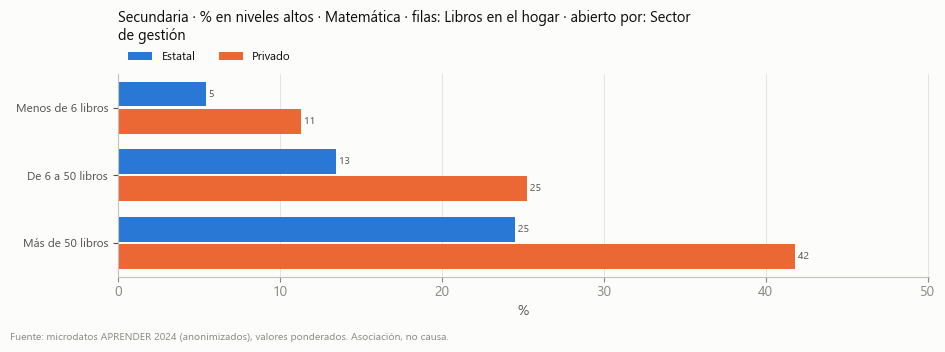

In [3]:
SUPERFICIE, TINTA, TINTA_2, TENUE, GRILLA, EJE = '#fcfcfb', '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
AZUL, NARANJA, AQUA, ROJO, NEUTRO = '#2a78d6', '#eb6834', '#1baf7a', '#e34948', '#f0efec'
SERIES = [AZUL, NARANJA, AQUA]                                  # categórica validada (orden fijo)
SECUENCIAL = LinearSegmentedColormap.from_list('secuencial', ['#f4f8fe', '#cde2fb', '#86b6ef', '#2a78d6', '#184f95', '#0d366b'])
DIVERGENTE = LinearSegmentedColormap.from_list('divergente', [ROJO, NEUTRO, AZUL])
plt.rcParams.update({
    'figure.dpi': 100, 'figure.facecolor': SUPERFICIE, 'axes.facecolor': SUPERFICIE, 'savefig.facecolor': SUPERFICIE,
    'font.family': 'sans-serif', 'font.sans-serif': ['Segoe UI', 'DejaVu Sans', 'Arial'],
    'text.color': TINTA, 'axes.labelcolor': TINTA_2, 'axes.edgecolor': EJE, 'axes.titlecolor': TINTA,
    'xtick.color': TENUE, 'ytick.color': TINTA_2, 'axes.grid': True, 'grid.color': GRILLA, 'grid.linewidth': 0.6,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.axisbelow': True})
ULTIMO = {}

def _cats(base, nombre, datos):
    col, orden, etq = VARIABLES[base][nombre]
    presentes = set(datos[col].dropna().unique())
    return col, [o for o in orden if o in presentes], etq

def explorar(base='Secundaria', medida='% en niveles altos', filas='Libros en el hogar', abrir_por=None, area=None,
             provincia=None, sector=None, ambito=None, nse=None, grafico=True, mostrar=True):
    df = BASES[base]
    area = area or next(iter(AREAS[base]))
    desemp, puntaje, peso, niveles, altos, bajos = AREAS[base][area]
    filtros = []
    if provincia: df = df[df.provincia == provincia]; filtros.append(provincia)
    if sector: df = df[df.sector == sector]; filtros.append(sector)
    if ambito and base == 'Secundaria': df = df[df.ambito == ambito]; filtros.append(ambito)
    if nse and base == 'Primaria': df = df[df.NSE_escuela == nse]; filtros.append(f'NSE {nse}')
    if abrir_por == filas: abrir_por = None
    if medida == 'Distribución de niveles': abrir_por = None

    cf, orden_f, etq_f = _cats(base, filas, df)
    claves = [cf]
    if abrir_por:
        ca, orden_a, etq_a = _cats(base, abrir_por, df); claves.append(ca)
    if medida == '% de estudiantes':
        x = df[df[cf].notna() & df.ponder.notna()]
        if abrir_por: x = x[x[ca].notna()]
        w = x.ponder
    else:
        x = df[df[desemp].notna() & df[peso].notna() & df[cf].notna()]
        if abrir_por: x = x[x[ca].notna()]
        w = x[peso]
    g = [x[c] for c in claves]
    n = x.groupby(g).size()
    if medida in ('% en niveles altos', '% en niveles bajos'):
        sel = altos if medida == '% en niveles altos' else bajos
        v = 100 * w.where(x[desemp].isin(sel), 0).groupby(g).sum() / w.groupby(g).sum()
    elif medida == 'Puntaje medio':
        ok = x[puntaje].notna()
        v = (x[puntaje] * w)[ok].groupby([c[ok] for c in g]).sum() / w[ok].groupby([c[ok] for c in g]).sum()
    elif medida == '% de estudiantes':
        tot = w.groupby(g).sum()
        v = 100 * tot / (tot.groupby(level=0).transform('sum') if abrir_por else tot.sum())
    elif medida == 'Distribución de niveles':
        v = (100 * w.groupby([x[cf], x[desemp]]).sum() / w.groupby(x[cf]).sum()).unstack().reindex(columns=niveles)
        n = x.groupby(cf).size()

    if medida == 'Distribución de niveles':
        tabla = v.reindex(orden_f).rename(index=lambda i: etq_f.get(i, i))
        tabla_n = n.reindex(orden_f).rename(index=lambda i: etq_f.get(i, i)).to_frame('n')
    elif abrir_por:
        tabla = v.unstack().reindex(index=orden_f, columns=orden_a).rename(index=lambda i: etq_f.get(i, i), columns=lambda c: etq_a.get(c, c))
        tabla_n = n.unstack().reindex(index=orden_f, columns=orden_a).rename(index=lambda i: etq_f.get(i, i), columns=lambda c: etq_a.get(c, c))
    else:
        tabla = v.reindex(orden_f).rename(index=lambda i: etq_f.get(i, i)).to_frame(medida)
        tabla_n = n.reindex(orden_f).rename(index=lambda i: etq_f.get(i, i)).to_frame('n')
    tabla.index.name = tabla_n.index.name = filas
    if abrir_por: tabla.columns.name = tabla_n.columns.name = abrir_por
    que = medida if medida in ('% de estudiantes',) else f'{medida} · {area}'
    titulo = f'{base} · {que} · filas: {filas}' + (f' · abierto por: {abrir_por}' if abrir_por else '') + (f' · {", ".join(filtros)}' if filtros else '')
    ULTIMO.update(tabla=tabla, n=tabla_n, titulo=titulo)

    if mostrar:
        display(HTML(f'<b>{titulo}</b>'))
        chica = tabla_n.reindex_like(tabla) < N_MIN if tabla_n.shape == tabla.shape else pd.DataFrame(False, index=tabla.index, columns=tabla.columns).apply(lambda c: tabla_n['n'] < N_MIN)
        fmt = tabla.map(lambda v: '' if pd.isna(v) else f'{v:.1f}') + chica.map(lambda b: ' †' if b else '')
        display(fmt)
        with pd.option_context('display.max_columns', 30):
            display(HTML('<small>n (estudiantes sin ponderar)</small>')); display(tabla_n)
    if grafico and len(tabla):
        dibujar(tabla, medida, titulo, base, niveles)
    return tabla, tabla_n

def dibujar(tabla, medida, titulo, base, niveles):
    filas_n = len(tabla)
    if medida == 'Distribución de niveles':
        fig, ax = plt.subplots(figsize=(10, 0.42 * filas_n + 1.4))
        colores = [DIVERGENTE(i / (len(niveles) - 1)) for i in range(len(niveles))]
        izq = np.zeros(filas_n)
        for niv, col in zip(tabla.columns, colores):
            vals = tabla[niv].fillna(0).values
            ax.barh(range(filas_n), vals, left=izq, color=col, label=niv, height=0.72, edgecolor=SUPERFICIE, linewidth=1.5)
            for i, (l, v) in enumerate(zip(izq, vals)):
                if v >= 6: ax.text(l + v / 2, i, f'{v:.0f}', ha='center', va='center', fontsize=8, color=TINTA)
            izq += vals
        ax.set_xlim(0, 100); ax.legend(frameon=False, fontsize=8, ncol=len(niveles), loc='lower left', bbox_to_anchor=(0, 1.0))
    elif tabla.shape[1] == 1:
        fig, ax = plt.subplots(figsize=(9, 0.38 * filas_n + 1.2))
        vals = tabla.iloc[:, 0]
        ax.barh(range(filas_n), vals, color=AZUL, height=0.7)
        for i, v in enumerate(vals):
            if pd.notna(v): ax.text(v, i, f' {v:.1f}', va='center', fontsize=8, color=TINTA_2)
    elif tabla.shape[1] <= 3:
        k = tabla.shape[1]; h = 0.8 / k
        fig, ax = plt.subplots(figsize=(9.5, 0.33 * filas_n * k + 1.4))
        for j, (col, color) in enumerate(zip(tabla.columns, SERIES)):
            pos = np.arange(filas_n) + (j - (k - 1) / 2) * h
            ax.barh(pos, tabla[col], height=h * 0.92, color=color, label=col)
            for p, v in zip(pos, tabla[col]):
                if pd.notna(v): ax.text(v, p, f' {v:.0f}', va='center', fontsize=7.5, color=TINTA_2)
        ax.legend(frameon=False, fontsize=8.5, loc='lower left', bbox_to_anchor=(0, 1.0), ncol=k)
    else:
        fig, ax = plt.subplots(figsize=(0.62 * tabla.shape[1] + 3.5, 0.38 * filas_n + 1.8))
        m = tabla.values.astype(float)
        ax.imshow(m, cmap=SECUENCIAL, aspect='auto', vmin=np.nanmin(m) if medida == 'Puntaje medio' else 0, vmax=np.nanmax(m))
        ax.set_xticks(range(tabla.shape[1])); ax.set_xticklabels([textwrap.fill(str(c), 14) for c in tabla.columns], fontsize=8,
                           rotation=0 if (tabla.shape[1] <= 8 and max(len(str(c)) for c in tabla.columns) <= 14) else 90)
        lim = np.nanmin(m) + (np.nanmax(m) - np.nanmin(m)) * 0.55 if medida == 'Puntaje medio' else np.nanmax(m) * 0.55
        for (r, q), v in np.ndenumerate(m):
            if not np.isnan(v): ax.text(q, r, f'{v:.0f}', ha='center', va='center', fontsize=7, color=SUPERFICIE if v > lim else TINTA)
        ax.grid(False)
    ax.set_yticks(range(filas_n)); ax.set_yticklabels([textwrap.fill(str(i), 30) for i in tabla.index], fontsize=8.5)
    if tabla.shape[1] <= 3 or medida == 'Distribución de niveles':
        ax.set_ylim(filas_n - 0.5, -0.5)   # primera categoría arriba
    if tabla.shape[1] <= 3 or medida == 'Distribución de niveles':
        ax.grid(axis='y', visible=False)
        ax.set_xlabel('puntaje' if medida == 'Puntaje medio' else '%')
        if medida != 'Puntaje medio' and medida != 'Distribución de niveles': ax.set_xlim(0, min(100, np.nanmax(tabla.values) * 1.15 + 2))
    ax.set_title(textwrap.fill(titulo, 95), loc='left', fontsize=10.5, pad=24 if (medida == 'Distribución de niveles' or 1 < tabla.shape[1] <= 3) else 8)
    fuente = ('Fuente: microdatos APRENDER 2024 (anonimizados), valores ponderados. ' +
              ('Primaria 3° es muestral. ' if base == 'Primaria' else '') + 'Asociación, no causa.')
    fig.tight_layout()
    fig.text(0.01, 0, fuente, fontsize=7.5, color=TENUE, ha='left', va='top')
    plt.show()

def descargar_ultima(nombre='cruce_microdatos'):
    """Guarda la última tabla calculada (valores + n) en un .xlsx y, en Colab, lo descarga."""
    assert ULTIMO, 'Primero calculá un cruce.'
    ruta = os.path.abspath(re.sub(r'[^A-Za-z0-9_-]+', '_', nombre) + '.xlsx')
    with pd.ExcelWriter(ruta, engine='openpyxl') as xw:
        pd.DataFrame({'cruce': [ULTIMO['titulo']]}).to_excel(xw, sheet_name='descripcion', index=False)
        ULTIMO['tabla'].round(3).to_excel(xw, sheet_name='valores')
        ULTIMO['n'].to_excel(xw, sheet_name='n')
    if in_colab():
        from google.colab import files
        files.download(ruta)
    print('Guardado:', ruta)

_ = explorar('Secundaria', '% en niveles altos', 'Libros en el hogar', 'Sector de gestión', area='Matemática')

---
## 3 · Explorador interactivo
Cambiá cualquier menú y el resultado se actualiza. Si los menús no aparecen, ejecutá de nuevo esta celda. El botón descarga la
tabla que estás viendo (valores y *n*).

In [4]:
w_base = W.Dropdown(options=list(BASES), value='Secundaria', description='Base', layout=W.Layout(width='260px'))
w_medida = W.Dropdown(options=MEDIDAS, value='% en niveles altos', description='Medida', layout=W.Layout(width='320px'))
w_area = W.Dropdown(options=list(AREAS['Secundaria']), description='Área', layout=W.Layout(width='240px'))
w_filas = W.Dropdown(options=list(VARIABLES['Secundaria']), value='Libros en el hogar', description='Filas', layout=W.Layout(width='380px'))
w_abrir = W.Dropdown(options=['(ninguna)'] + list(VARIABLES['Secundaria']), value='Sector de gestión', description='Abrir por', layout=W.Layout(width='380px'))
w_prov = W.Dropdown(options=['Todas'] + PROVINCIAS, value='Todas', description='Provincia', layout=W.Layout(width='280px'))
w_sector = W.Dropdown(options=['Todos', 'Estatal', 'Privado'], value='Todos', description='Sector', layout=W.Layout(width='220px'))
w_ambito = W.Dropdown(options=['Todos', 'Urbano', 'Rural'], value='Todos', description='Ámbito', layout=W.Layout(width='220px'))
w_nse = W.Dropdown(options=['Todos'] + NSE, value='Todos', description='NSE escuela', layout=W.Layout(width='240px'))
for w_ in (w_nse,): w_.style.description_width = 'initial'
b_desc = W.Button(description='Descargar esta tabla (.xlsx)', icon='download', layout=W.Layout(width='260px'))
salida = W.Output()
_ocupado = {'v': False}

def _cambio_base(_=None):
    _ocupado['v'] = True
    base = w_base.value
    w_area.options = list(AREAS[base])
    vs = list(VARIABLES[base])
    filas_prev, abrir_prev = w_filas.value, w_abrir.value
    w_filas.options = vs; w_filas.value = filas_prev if filas_prev in vs else vs[1]
    w_abrir.options = ['(ninguna)'] + vs; w_abrir.value = abrir_prev if abrir_prev in vs else '(ninguna)'
    w_ambito.disabled = base != 'Secundaria'; w_nse.disabled = base != 'Primaria'
    _ocupado['v'] = False
    _actualizar()

def _actualizar(_=None):
    if _ocupado['v']: return
    w_abrir.disabled = w_medida.value == 'Distribución de niveles'
    w_area.disabled = w_medida.value == '% de estudiantes'
    salida.clear_output(wait=True)
    with salida:
        try:
            explorar(w_base.value, w_medida.value, w_filas.value,
                     None if w_abrir.value == '(ninguna)' else w_abrir.value, area=w_area.value,
                     provincia=None if w_prov.value == 'Todas' else w_prov.value,
                     sector=None if w_sector.value == 'Todos' else w_sector.value,
                     ambito=None if w_ambito.value == 'Todos' else w_ambito.value,
                     nse=None if w_nse.value == 'Todos' else w_nse.value)
        except Exception as e:
            print('No se pudo calcular este cruce:', e)

w_base.observe(_cambio_base, names='value')
for w_ in (w_medida, w_area, w_filas, w_abrir, w_prov, w_sector, w_ambito, w_nse):
    w_.observe(_actualizar, names='value')
b_desc.on_click(lambda _: descargar_ultima('cruce_' + re.sub(r'[^A-Za-z0-9]+', '_', _n(ULTIMO.get('titulo', 'microdatos')))[:80]))

UI = W.VBox([W.HBox([w_base, w_medida, w_area]), W.HBox([w_filas, w_abrir]),
             W.HBox([w_prov, w_sector, w_ambito, w_nse]), b_desc, salida])
_cambio_base()
display(UI)

---
## 4 · Cruces de ejemplo
Algunos cruces listos (se pueden copiar y cambiar los argumentos de `explorar`). Después de cualquiera, `descargar_ultima()`
guarda esa tabla.

Libros en el hogar,Menos de 6 libros,De 6 a 50 libros,Más de 50 libros
Nivel educativo de la madre,,,
Hasta secundaria incompleta,49.6,40.7,9.6
Secundaria completa a terciario incompleto,32.4,48.0,19.6
Terciario / universitario completo,15.0,43.8,41.2


Libros en el hogar,Menos de 6 libros,De 6 a 50 libros,Más de 50 libros
Nivel educativo de la madre,,,
Hasta secundaria incompleta,60629,50302,11955
Secundaria completa a terciario incompleto,42741,66068,27523
Terciario / universitario completo,17906,54500,52281


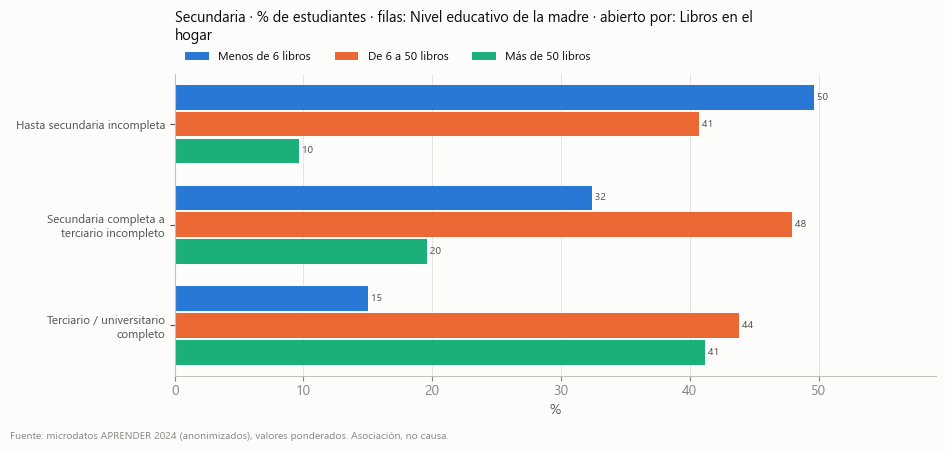

In [5]:
# 4.1 ¿Cuánto se superponen dos variables de contexto? Libros en el hogar según educación de la madre (Secundaria)
_ = explorar('Secundaria', '% de estudiantes', 'Nivel educativo de la madre', 'Libros en el hogar')

Nivel en Matemática,Por debajo del nivel básico,Básico,Satisfactorio,Avanzado
Nivel en Lengua,,,,
Por debajo del nivel básico,85.0,12.9,2.1,
Básico,71.5,23.6,4.9,0.0 †
Satisfactorio,42.6,37.0,20.3,0.1
Avanzado,13.1,31.4,54.6,0.9


Nivel en Matemática,Por debajo del nivel básico,Básico,Satisfactorio,Avanzado
Nivel en Lengua,,,,
Por debajo del nivel básico,64295.0,10185.0,1720.0,NaN
Básico,51870.0,17761.0,3868.0,5.0
Satisfactorio,66922.0,60357.0,34309.0,102.0
Avanzado,6649.0,16389.0,29479.0,471.0


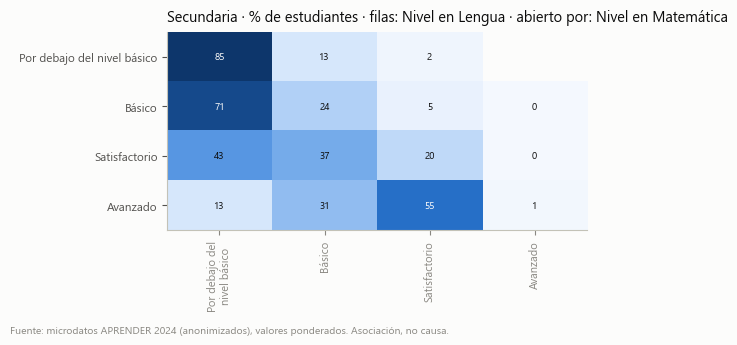

In [6]:
# 4.2 Lengua y Matemática del mismo estudiante: nivel en Matemática según nivel en Lengua
_ = explorar('Secundaria', '% de estudiantes', 'Nivel en Lengua', 'Nivel en Matemática')

Sexo,Femenino,Masculino
Provincia,,
Buenos Aires,13.7,20.5
CABA,29.8,40.0
Catamarca,5.8,11.7
Chaco,5.7,11.4
Chubut,13.2,22.1
Córdoba,20.1,28.6
Corrientes,7.6,14.3
Entre Ríos,13.8,23.2
Formosa,9.5,13.1


Sexo,Femenino,Masculino
Provincia,,
Buenos Aires,67736,63227
CABA,11112,11154
Catamarca,1994,1765
Chaco,4713,4019
Chubut,2485,2353
Córdoba,19471,17580
Corrientes,5352,4374
Entre Ríos,5265,4524
Formosa,2763,2456


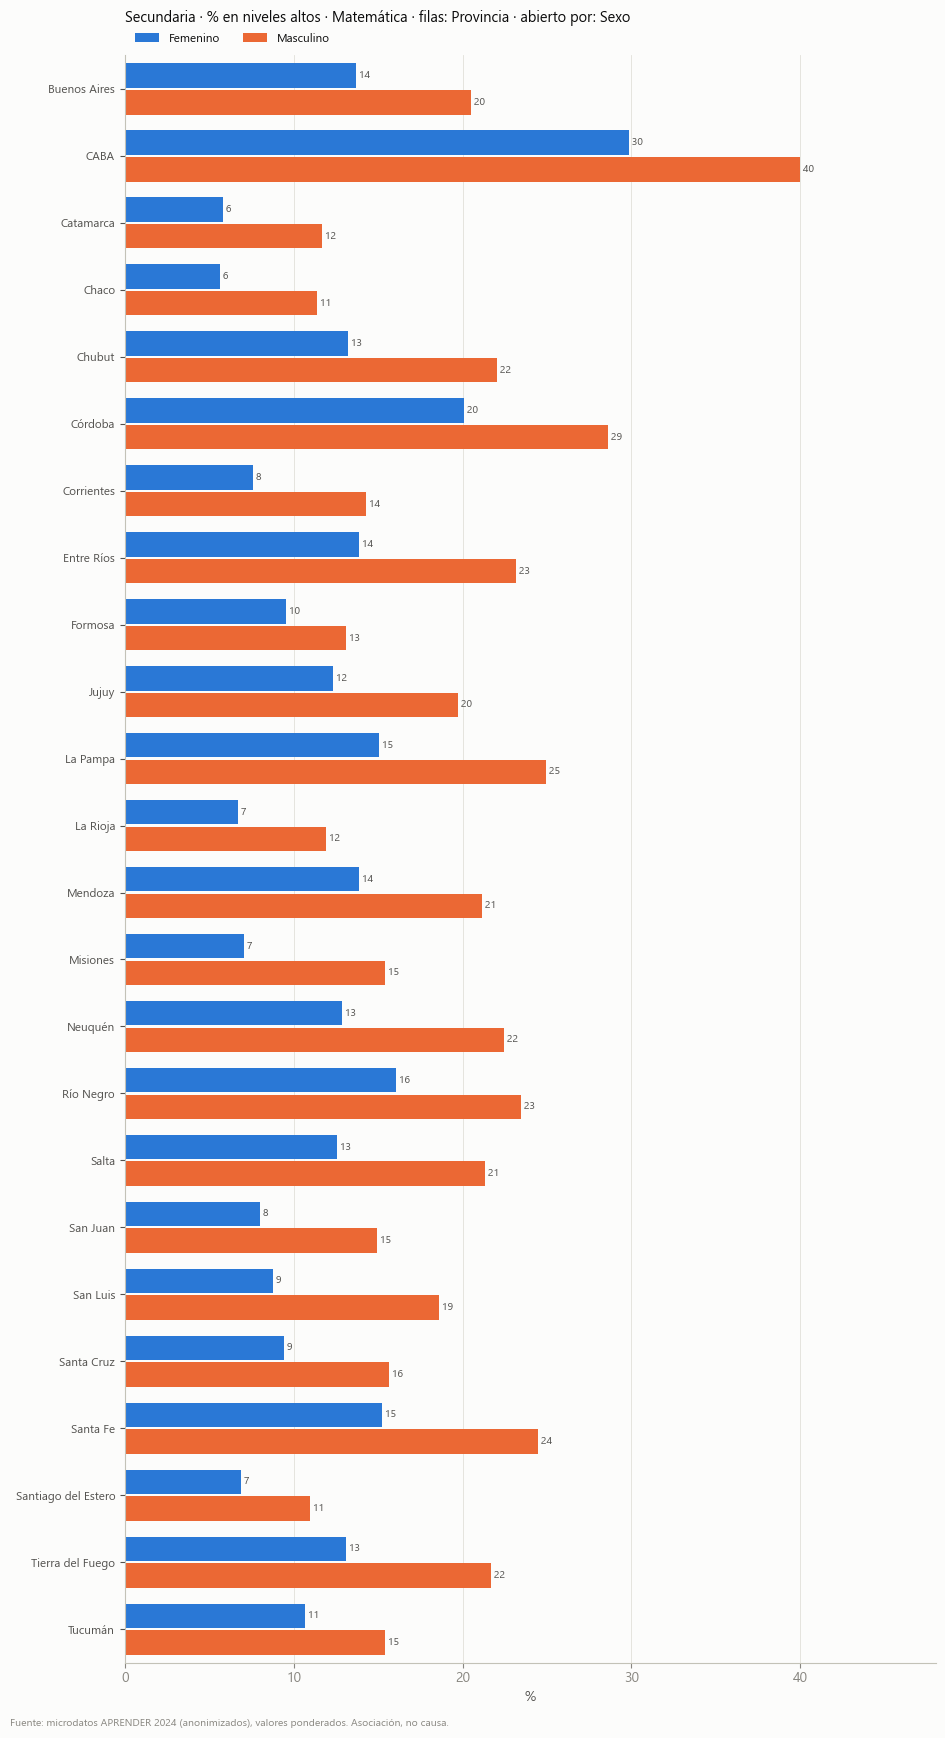

In [7]:
# 4.3 Matemática por provincia y sexo (% Satisfactorio + Avanzado)
_ = explorar('Secundaria', '% en niveles altos', 'Provincia', 'Sexo', area='Matemática')

mdesemp,Por debajo del nivel básico,Básico,Satisfactorio,Avanzado
Recursos del hogar (0–5),,,,
0,69.0,23.6,7.4,
1,69.8,23.2,7.0,0.0
2,64.8,25.3,9.8,0.0
3,58.3,27.7,13.9,0.1
4,47.6,30.2,22.0,0.2
5,33.2,29.9,36.2,0.7


,n
Recursos del hogar (0–5),
0,14043
1,52171
2,80141
3,52657
4,22322
5,7424


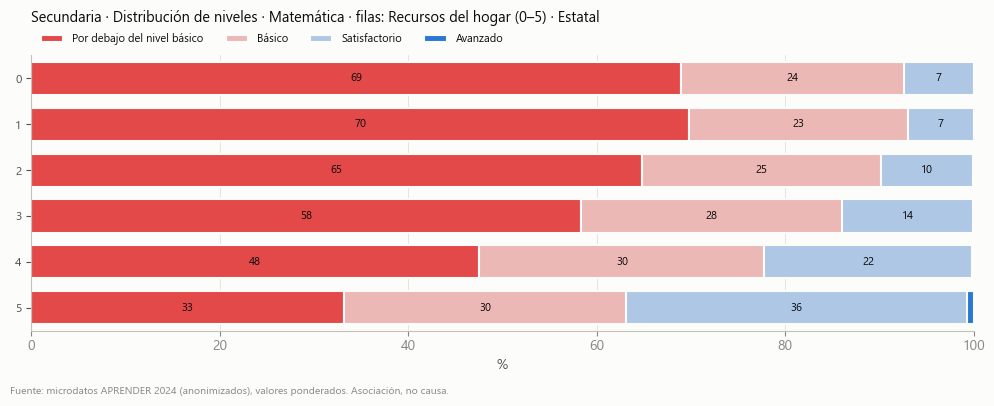

In [8]:
# 4.4 Distribución de niveles en Matemática según recursos del hogar, solo escuelas estatales
_ = explorar('Secundaria', 'Distribución de niveles', 'Recursos del hogar (0–5)', area='Matemática', sector='Estatal')

NSE de la escuela,Bajo,Medio Bajo,Medio,Medio Alto,Alto
Asistencia al jardín,,,,,
Sala de 3,31.3,37.9,44.5,55.2,70.2
Sala de 4,36.9,36.1,43.5,52.3,66.3
Sala de 5 o no asistió,29.6,29.6,36.4,42.4,53.8


NSE de la escuela,Bajo,Medio Bajo,Medio,Medio Alto,Alto
Asistencia al jardín,,,,,
Sala de 3,3955,4433,6364,8252,14661
Sala de 4,4444,3630,4645,5019,4910
Sala de 5 o no asistió,5187,4137,4632,4394,3767


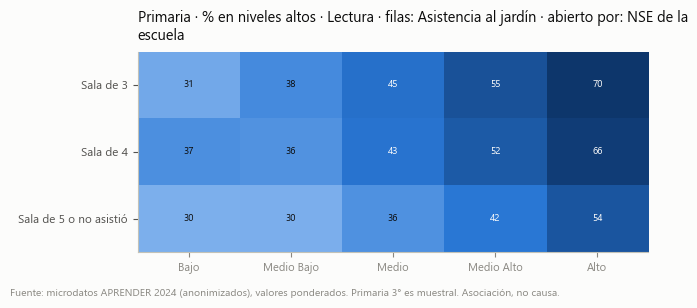

In [9]:
# 4.5 Primaria 3°: lectura (% Niveles IV–V) según jardín, abierto por NSE de la escuela
_ = explorar('Primaria', '% en niveles altos', 'Asistencia al jardín', 'NSE de la escuela')

Alguien de la familia le lee,Sí,No
Nivel en Lectura,,
Lector incipiente,49.7,50.3
Nivel I,52.5,47.5
Nivel II,44.7,55.3
Nivel III,35.7,64.3
Nivel IV,30.3,69.7
Nivel V,28.6,71.4


Alguien de la familia le lee,Sí,No
Nivel en Lectura,,
Lector incipiente,990,1046
Nivel I,3170,2737
Nivel II,6545,7939
Nivel III,7392,13074
Nivel IV,6954,16843
Nivel V,4741,12713


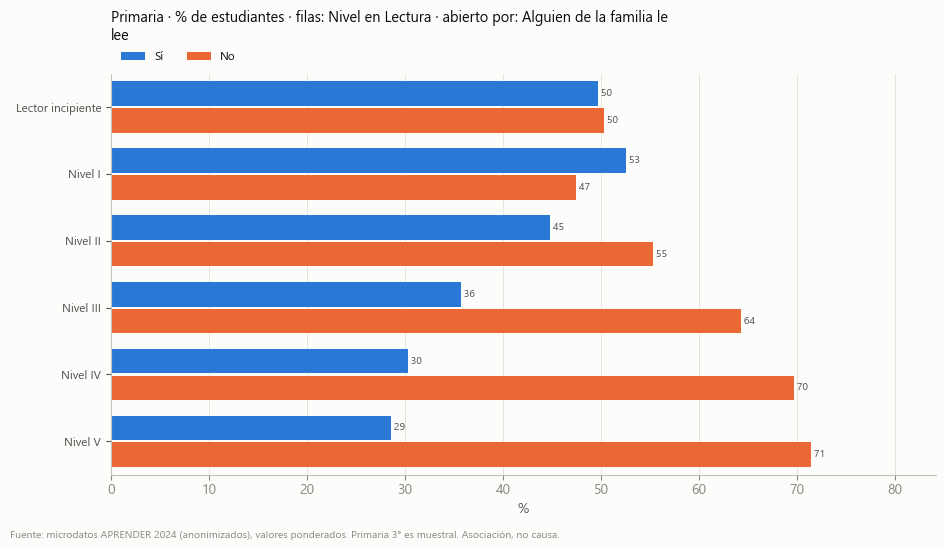

In [10]:
# 4.6 Primaria 3°: ¿a quiénes les lee alguien de la familia? Según su nivel de lectura
_ = explorar('Primaria', '% de estudiantes', 'Nivel en Lectura', 'Alguien de la familia le lee')